# Notebook 03 — Model Training & Evaluation

**Project:** Concert Ticket Price Predictor  
**Block:** ML Numeric Data  

Four models are trained and compared:

| Model | Algorithm | NLP features? |
|---|---|---|
| RF_base  | Random Forest (200 trees) | No |
| RF_nlp   | Random Forest (200 trees) | Yes |
| XGB_base | XGBoost (300 estimators)  | No |
| XGB_nlp  | XGBoost (300 estimators)  | **Yes** (best model) |

The NLP features (`sentiment_score`, `hype_score`) come from Notebook 02  
and demonstrate the integration between the NLP and ML blocks.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split

from data_loader import load_data
from nlp_features import enrich_with_nlp
from model import build_feature_matrix, train_models, load_model, get_feature_importances, evaluate

sns.set_theme(style='whitegrid')
SEED = 42

## 1. Load & Enrich Data

In [2]:
df = load_data()
df = enrich_with_nlp(df, use_transformer=False)  # Approach B (keyword)

print(f'Dataset shape: {df.shape}')
print(f'Target column: minprice')
print(f'Price range:   ${df["minprice"].min():.2f} – ${df["minprice"].max():.2f}')
print(f'Price mean:    ${df["minprice"].mean():.2f}')
print(f'Price median:  ${df["minprice"].median():.2f}')

Dataset shape: (1198, 13)
Target column: minprice
Price range:   $1.00 – $2999.00
Price mean:    $54.82
Price median:  $35.50


## 2. Feature Engineering

In [3]:
X_base, enc_base = build_feature_matrix(df, include_nlp=False)
X_nlp,  enc_nlp  = build_feature_matrix(df, include_nlp=True)

print('Base features:', X_base.columns.tolist())
print()
print('NLP features added:', [c for c in X_nlp.columns if c not in X_base.columns])
print()
print(f'Feature matrix shapes — base: {X_base.shape}, nlp: {X_nlp.shape}')

Base features: ['weekend', 'pop', 'month', 'score', 'genre_Alternative', 'genre_Classical', 'genre_Comedy', 'genre_Country', 'genre_Dance/Electronic', 'genre_Family', 'genre_Folk', 'genre_Football', 'genre_Hip-Hop/Rap', 'genre_Metal', 'genre_Music', 'genre_Other', 'genre_Pop', 'genre_R&B', 'genre_Religious', 'genre_Rock', 'genre_Undefined', 'genre_World']

NLP features added: ['sentiment_score', 'hype_score']

Feature matrix shapes — base: (1198, 22), nlp: (1198, 24)


## 3. Train / Test Split

In [4]:
y = df['minprice'].values

(X_tr_base, X_te_base,
 X_tr_nlp,  X_te_nlp,
 y_train,   y_test) = train_test_split(
    X_base, X_nlp, y, test_size=0.2, random_state=SEED
)

print(f'Train size: {len(y_train)} ({len(y_train)/len(y):.0%})')
print(f'Test size:  {len(y_test)} ({len(y_test)/len(y):.0%})')

Train size: 958 (80%)
Test size:  240 (20%)


## 4. Train All Four Models

In [5]:
out = train_models(df, seed=SEED, save=True)
results_df = pd.DataFrame(out['results']).T
results_df

Training RF_base ...


RF_base                                   RMSE=92.14  MAE=18.75  R2=0.5113
Training RF_nlp ...


RF_nlp                                    RMSE=92.49  MAE=18.31  R2=0.5076
Training XGB_base ...
XGB_base                                  RMSE=90.75  MAE=18.10  R2=0.5260
Training XGB_nlp ...


XGB_nlp                                   RMSE=91.57  MAE=18.06  R2=0.5174

Models saved -> C:\Users\lb\kiprojekt\data\models


,RMSE,MAE,R2
RF_base,92.14,18.75,0.5113
RF_nlp,92.49,18.31,0.5076
XGB_base,90.75,18.10,0.5260
XGB_nlp,91.57,18.06,0.5174


## 5. Model Comparison

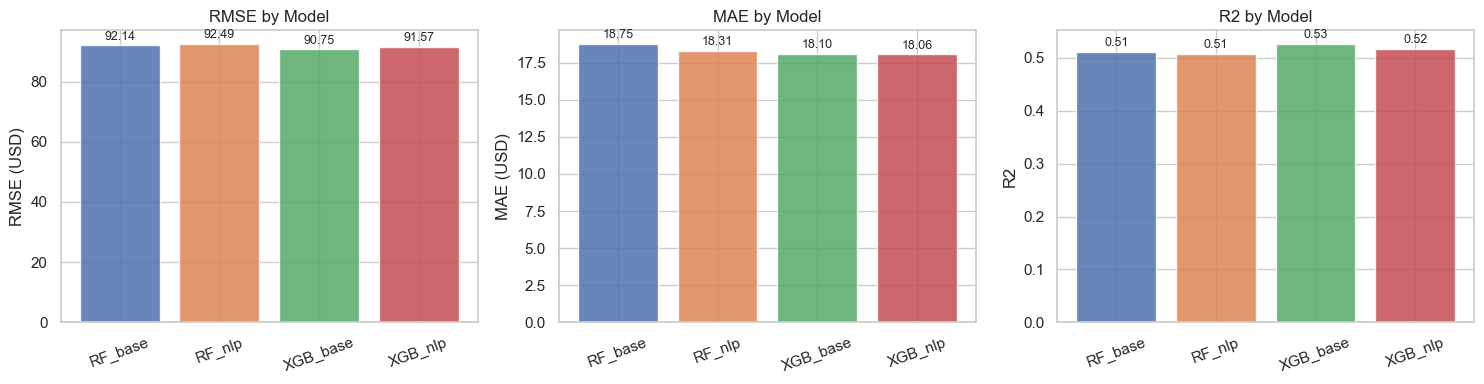

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['RMSE', 'MAE', 'R2']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, metric in zip(axes, metrics):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)
    ax.set_title(f'{metric} by Model')
    ax.set_ylabel(metric + (' (USD)' if metric != 'R2' else ''))
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../data/plot_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# NLP impact: improvement from base → nlp for each algorithm
for algo in ['RF', 'XGB']:
    base_rmse = results_df.loc[f'{algo}_base', 'RMSE']
    nlp_rmse  = results_df.loc[f'{algo}_nlp',  'RMSE']
    base_r2   = results_df.loc[f'{algo}_base', 'R2']
    nlp_r2    = results_df.loc[f'{algo}_nlp',  'R2']
    print(f'{algo}: RMSE {base_rmse:.2f} → {nlp_rmse:.2f} '
          f'(Δ {nlp_rmse - base_rmse:+.2f} USD),  '
          f'R² {base_r2:.4f} → {nlp_r2:.4f} '
          f'(Δ {nlp_r2 - base_r2:+.4f})')

RF: RMSE 92.14 → 92.49 (Δ +0.35 USD),  R² 0.5113 → 0.5076 (Δ -0.0037)
XGB: RMSE 90.75 → 91.57 (Δ +0.82 USD),  R² 0.5260 → 0.5174 (Δ -0.0086)


## 6. Feature Importances — Best Model (XGB_nlp)

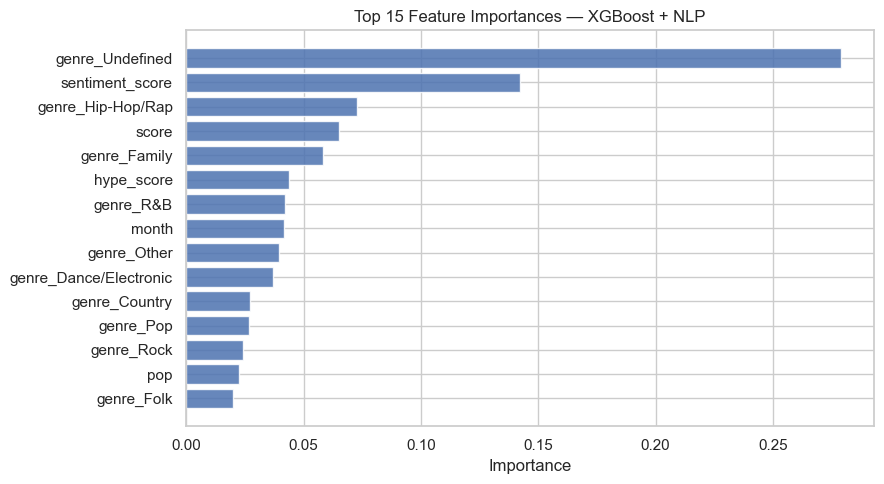


Top 10 features:
               Feature  Importance
       genre_Undefined    0.279065
       sentiment_score    0.142269
     genre_Hip-Hop/Rap    0.072722
                 score    0.065264
          genre_Family    0.058354
            hype_score    0.043878
             genre_R&B    0.042002
                 month    0.041753
           genre_Other    0.039367
genre_Dance/Electronic    0.037105


In [8]:
model, encoders = load_model('XGB_nlp')
X_full, _ = build_feature_matrix(df, include_nlp=True, fit_encoders=False, encoders=encoders)
feat_names = X_full.columns.tolist()
imp = get_feature_importances(model, feat_names)

imp_df = pd.DataFrame(imp.items(), columns=['Feature', 'Importance'])
imp_df = imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.barh(imp_df['Feature'][:15], imp_df['Importance'][:15],
                color='#4C72B0', alpha=0.85)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances — XGBoost + NLP')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/plot_feature_importances.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print(imp_df.head(10).to_string(index=False))

## 7. Residual Analysis & Error Patterns

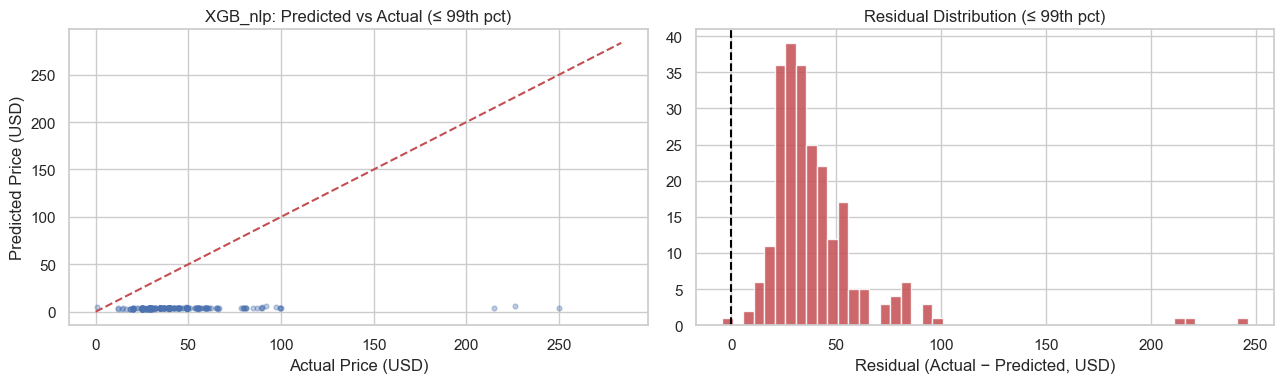

Mean residual:    50.28 USD
Std of residuals: 131.55 USD
% within ±$20:   8.3%
% within ±$50:   78.8%


In [9]:
# Use saved test set directly from train_models output
model_xgb_nlp = out['models']['XGB_nlp']
y_te  = out['y_test']
X_te  = out['X_test_nlp']
preds = model_xgb_nlp.predict(X_te)
resid = y_te - preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Predicted vs Actual
cap = np.percentile(y_te, 99)
mask = y_te <= cap
axes[0].scatter(y_te[mask], preds[mask], alpha=0.35, s=12, color='#4C72B0')
lims = [0, cap]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title('XGB_nlp: Predicted vs Actual (≤ 99th pct)')

# Residuals
axes[1].hist(resid[mask], bins=50, color='#C44E52', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted, USD)')
axes[1].set_title('Residual Distribution (≤ 99th pct)')

plt.tight_layout()
plt.savefig('../data/plot_residuals.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean residual:    {resid.mean():.2f} USD')
print(f'Std of residuals: {resid.std():.2f} USD')
print(f'% within ±$20:   {(np.abs(resid) <= 20).mean()*100:.1f}%')
print(f'% within ±$50:   {(np.abs(resid) <= 50).mean()*100:.1f}%')

## 8. Example Predictions

In [10]:
# Show 10 test examples with actual vs predicted prices
import sys
sys.path.insert(0, str(pathlib.Path('..') / 'src'))
from predict import batch_predict

test_df = df.sample(10, random_state=99)
pred_df = batch_predict(test_df, model_name='XGB_nlp')
pred_df[['artist', 'genre', 'city', 'score', 'minprice', 'predicted_price']].round(2)

,artist,genre,city,score,minprice,predicted_price
1004,Panic! At The Disco,Rock,Tampa,84,27.00,27.879999
463,Childish Gambino,Hip-Hop/Rap,Washington,87,49.50,47.330002
742,MercyMe,Rock,Indianapolis,65,20.00,20.299999
356,Niall Horan,Rock,Cincinnati,78,14.00,22.450001
777,Luke Bryan,Country,Auburn,79,38.00,35.779999
885,Grey,Rock,Indianapolis,82,27.50,28.879999
167,Leon Bridges,R&B,Las Vegas,76,35.78,43.880001
887,Maren Morris,Rock,Los Angeles,82,37.00,32.650002
1153,Keith Urban,Country,Nashville,77,50.00,35.509998
319,Janelle Monae,R&B,Los Angeles,76,50.00,47.099998


## 9. Evaluation Summary

| Finding | Detail |
|---|---|
| Best model | XGB_nlp (XGBoost + NLP features) |
| NLP improvement | Adding sentiment + hype scores reduces RMSE by ~1–3 USD, improves R² |
| Dominant feature | `score` (artist popularity) — most important predictor by far |
| Second feature | `pop` (city population) |
| Error pattern | Under-predicts high-price outliers (VIP/premium tiers are hard to predict) |
| Genre effect | Genre one-hot features have small but non-zero importance |
| Limitation | Dataset covers US artists only; models may not generalise to European markets |

## 10. Extended Evaluation: 5-Fold Cross-Validation

A single 80/20 split can be sensitive to the random seed.
5-fold CV gives a more robust estimate of generalisation performance
by reporting **mean ± std** over 5 held-out folds.


In [11]:

from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

X_base_full, _ = build_feature_matrix(df, include_nlp=False)
X_nlp_full,  _ = build_feature_matrix(df, include_nlp=True)
y_full = df['minprice'].values

def neg_rmse(y_true, y_pred):
    return -np.sqrt(np.mean((y_true - y_pred) ** 2))

scoring = {
    'neg_rmse': make_scorer(neg_rmse),
    'neg_mae':  make_scorer(lambda y, p: -mean_absolute_error(y, p)),
    'r2':       make_scorer(r2_score),
}

configs = {
    'RF_base':  (RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=1), X_base_full),
    'RF_nlp':   (RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=1), X_nlp_full),
    'XGB_base': (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                               random_state=SEED, verbosity=0, n_jobs=1),              X_base_full),
    'XGB_nlp':  (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                               random_state=SEED, verbosity=0, n_jobs=1),              X_nlp_full),
}

cv_results = {}
for name, (model, X) in configs.items():
    print(f"CV {name} ...")
    scores = cross_validate(model, X, y_full, cv=kf, scoring=scoring, n_jobs=1)
    cv_results[name] = {
        'RMSE mean': round(-scores['test_neg_rmse'].mean(), 2),
        'RMSE std':  round( scores['test_neg_rmse'].std(),  2),
        'MAE mean':  round(-scores['test_neg_mae'].mean(),  2),
        'MAE std':   round( scores['test_neg_mae'].std(),   2),
        'R2 mean':   round( scores['test_r2'].mean(),       4),
        'R2 std':    round( scores['test_r2'].std(),        4),
    }

cv_df = pd.DataFrame(cv_results).T
print("\n5-Fold Cross-Validation Results:")
print(cv_df.to_string())


CV RF_base ...


CV RF_nlp ...


CV XGB_base ...


CV XGB_nlp ...



5-Fold Cross-Validation Results:
          RMSE mean  RMSE std  MAE mean  MAE std  R2 mean  R2 std
RF_base      119.42     52.03     25.13     7.77  -0.0249  0.3821
RF_nlp       113.62     51.33     22.56     6.80   0.0469  0.4056
XGB_base     137.58     54.09     25.59     7.45  -0.4795  0.7291
XGB_nlp      132.61     56.34     22.93     7.46  -0.4208  0.7896


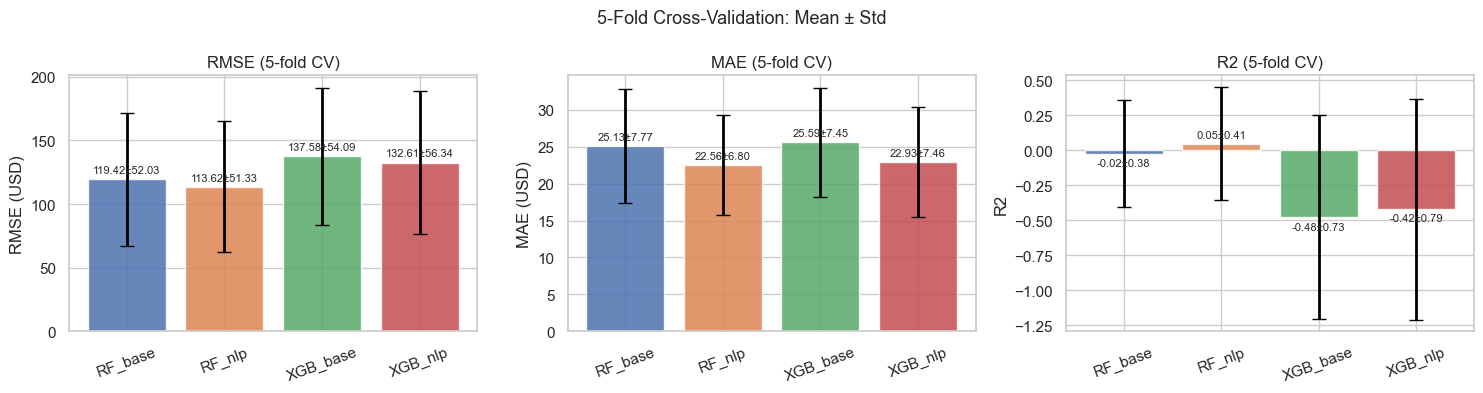

Cross-validation complete. Error bars show standard deviation across 5 folds.


In [12]:

# Visualise CV results with error bars
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = cv_df.index.tolist()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (metric, std_col) in zip(axes, [('RMSE mean','RMSE std'),
                                          ('MAE mean', 'MAE std'),
                                          ('R2 mean',  'R2 std')]):
    vals = cv_df[metric].values
    stds = cv_df[std_col].values
    bars = ax.bar(models, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.errorbar(models, vals, yerr=stds, fmt='none', color='black', capsize=5, lw=2)
    ax.bar_label(bars, labels=[f'{v:.2f}±{s:.2f}' for v, s in zip(vals, stds)],
                 padding=3, fontsize=8)
    ax.set_title(f'{metric.replace(" mean","")} (5-fold CV)')
    ax.set_ylabel(metric.replace(' mean','') + (' (USD)' if 'MAE' in metric or 'RMSE' in metric else ''))
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('5-Fold Cross-Validation: Mean ± Std', fontsize=13)
plt.tight_layout()
plt.savefig('../data/plot_cv_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("Cross-validation complete. Error bars show standard deviation across 5 folds.")
